<a href="https://colab.research.google.com/github/Myria255/BOOTCAMP-TTA/blob/main/Miniproject5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importation des librairires

In [ ]:
# Importation des bibliothèques principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importation des modules Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Chargement du fichier local que vous avez fourni
df = pd.read_csv(r'C:\Users\Debohi\Downloads\UCI Heart Disease Data\heart_disease_uci.csv')

# Suppression de la colonne 'id' et 'dataset' qui ne servent pas à la prédiction
df = df.drop(columns=['id', 'dataset'], errors='ignore')

# Affichage des premières lignes et des colonnes pour vérification
print("Colonnes lues :", list(df.columns))
df.head()

Colonnes lues : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Gestion des doublons, valeurs manquantes et aberrantes

In [ ]:
# A. GESTION DES DOUBLONS
nb_doublons = df.duplicated().sum()
print(f"Nombre de doublons détectés : {nb_doublons}")
if nb_doublons > 0:
    df = df.drop_duplicates()

# B. GESTION DES VALEURS MANQUANTES
print("\nValeurs manquantes par colonne avant nettoyage :")
print(df.isnull().sum())

# Dans ce dataset complet, nous supprimons les lignes contenant des valeurs manquantes
df = df.dropna()
print(f"\nDimensions du dataset après suppression des valeurs manquantes : {df.shape}")

# C. GESTION DES VALEURS ABERRANTES (OUTLIERS)
# Analyse et nettoyage des valeurs aberrantes sur le cholestérol ('chol')
Q1 = df['chol'].quantile(0.25)
Q3 = df['chol'].quantile(0.75)
IQR = Q3 - Q1
seuil_inf = Q1 - 1.5 * IQR
seuil_sup = Q3 + 1.5 * IQR

outliers_chol = df[(df['chol'] < seuil_inf) | (df['chol'] > seuil_sup)]
print(f"Nombre de valeurs aberrantes pour le cholestérol : {len(outliers_chol)}")

# Filtrage pour ne garder que les valeurs normales
df = df[(df['chol'] >= seuil_inf) & (df['chol'] <= seuil_sup)]

Nombre de doublons détectés : 2

Valeurs manquantes par colonne avant nettoyage :
age           0
sex           0
cp            0
trestbps     59
chol         29
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       307
ca          609
thal        484
num           0
dtype: int64

Dimensions du dataset après suppression des valeurs manquantes : (299, 14)
Nombre de valeurs aberrantes pour le cholestérol : 6


## Analyse Descriptive Univariée

Tableau des effectifs pour 'cp'
                 Effectif Absolu  Pourcentage (%)
cp                                               
asymptomatic                 140        47.781570
non-anginal                   81        27.645051
atypical angina               49        16.723549
typical angina                23         7.849829


C:\Users\Debohi\AppData\Local\Temp\ipykernel_16372\428911815.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cp', data=df, palette='pastel')


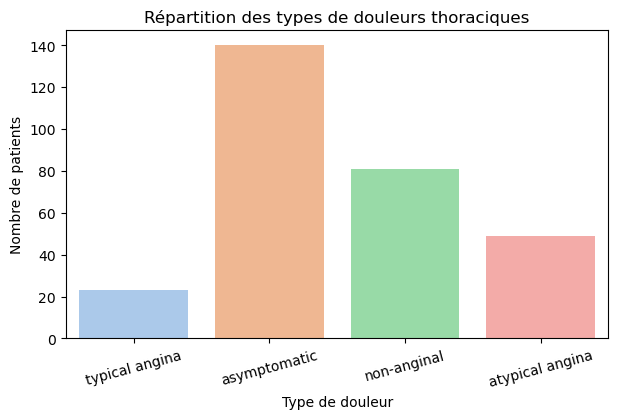


Statistiques descriptives de l'Âge
count    293.000000
mean      54.378840
std        9.046484
min       29.000000
25%       47.000000
50%       55.000000
75%       61.000000
max       77.000000
Name: age, dtype: float64


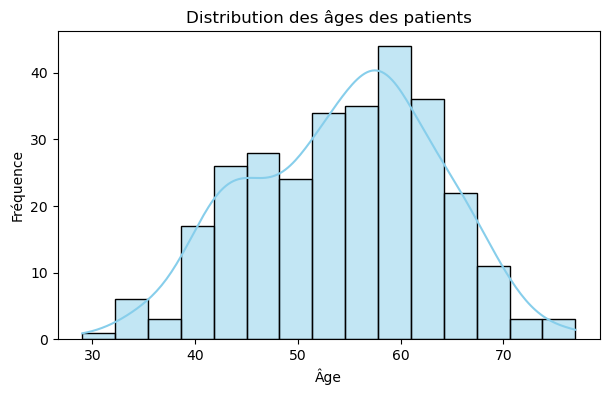

In [ ]:
# A. VARIABLE CATÉGORIELLE : 'cp' (Type de douleur thoracique)
print("Tableau des effectifs pour 'cp'")
table_cp = pd.DataFrame({
    'Effectif Absolu': df['cp'].value_counts(),
    'Pourcentage (%)': df['cp'].value_counts(normalize=True) * 100
})
print(table_cp)

# Diagramme en bâtons
plt.figure(figsize=(7, 4))
sns.countplot(x='cp', data=df, palette='pastel')
plt.title("Répartition des types de douleurs thoraciques")
plt.xlabel("Type de douleur")
plt.ylabel("Nombre de patients")
plt.xticks(rotation=15)
plt.show()

# B. VARIABLE CONTINUE : 'age'
print("\nStatistiques descriptives de l'Âge")
print(df['age'].describe())

# Histogramme
plt.figure(figsize=(7, 4))
sns.histplot(df['age'], bins=15, kde=True, color='skyblue')
plt.title("Distribution des âges des patients")
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.show()

## Analyse Descriptive Bivariée

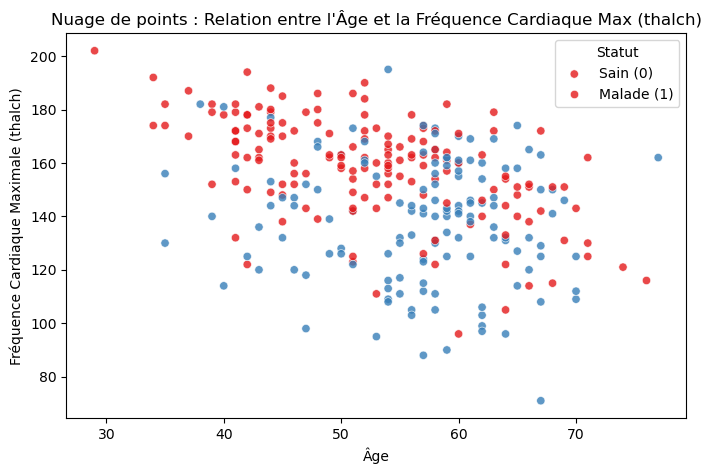

In [ ]:
# Création de la variable cible binaire : 0 = Sain, 1 = Malade
# Votre colonne s'appelle 'num'. 0 veut dire sain, les valeurs de 1 à 4 représentent les stades de la maladie.
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df = df.drop(columns=['num']) # On supprime l'ancienne colonne 'num' devenue inutile

# --- NUAGE DE POINTS (Scatter Plot) ---
plt.figure(figsize=(8, 5))
# Attention : la colonne fréquence cardiaque s'appelle 'thalch' dans votre fichier
sns.scatterplot(x='age', y='thalch', hue='target', data=df, palette='Set1', alpha=0.8)
plt.title("Nuage de points : Relation entre l'Âge et la Fréquence Cardiaque Max (thalch)")
plt.xlabel("Âge")
plt.ylabel("Fréquence Cardiaque Maximale (thalch)")
plt.legend(title="Statut", labels=["Sain (0)", "Malade (1)"])
plt.show()

## Encodage des données catégorielles textuelles

In [ ]:
# Identification automatique des colonnes textuelles à encoder
colonnes_texte = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# Encodage One-Hot
df_encoded = pd.get_dummies(df, columns=colonnes_texte, drop_first=True)

# Séparation des caractéristiques (X) et de la cible (y)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

## Entraînement du Modèle

In [ ]:
# Split 80% entraînement / 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalisation standard (Mise à l'échelle)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraînement de la Régression Logistique
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)
print("Modèle entraîné avec succès sur votre fichier CSV !")

Modèle entraîné avec succès sur votre fichier CSV !


## Évaluation du Modèle

--- Résumé des Performances ---
             Métrique  Valeur obtenue
Exactitude (Accuracy)        0.813559
            Précision        0.807692
      Rappel (Recall)        0.777778
             Score F1        0.792453

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        32
           1       0.81      0.78      0.79        27

    accuracy                           0.81        59
   macro avg       0.81      0.81      0.81        59
weighted avg       0.81      0.81      0.81        59



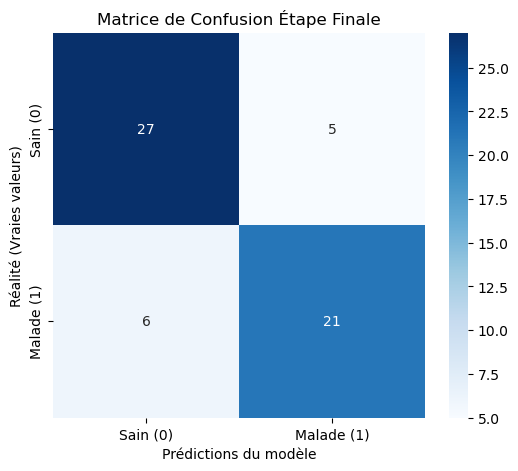

In [ ]:
# Prédictions
y_pred = model.predict(X_test_scaled)

# Calcul des métriques fondamentales
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_summary = pd.DataFrame({
    'Métrique': ['Exactitude (Accuracy)', 'Précision', 'Rappel (Recall)', 'Score F1'],
    'Valeur obtenue': [accuracy, precision, recall, f1]
})
print("--- Résumé des Performances ---")
print(metrics_summary.to_string(index=False))

print("\n--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))

# Matrice de Confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sain (0)', 'Malade (1)'],
            yticklabels=['Sain (0)', 'Malade (1)'])
plt.title("Matrice de Confusion Étape Finale")
plt.xlabel("Prédictions du modèle")
plt.ylabel("Réalité (Vraies valeurs)")
plt.show()